## Introduction et exploration des données


L'objectif de ce projet est d'améliorer la prévision déterministe de la concentration d'ozone dans certaines stations de prélèvement. Il s'agit d'un problème d'adaptation statistique d'une prévision locale de modèles à grande échelle en utilisant d'autres variables climatiques locales. Commençons par charger les données et effectuer une analyse exploratoire :

In [ ]:
# Installer les packages nécessaires
install.packages("ggplot2")        # Pour la visualisation graphique
install.packages("tidyverse")      # Pour les fonctions de manipulation de données
install.packages("gridExtra")      # Pour l'agencement des graphiques
install.packages("corrplot")       # Pour les visualisations de corrélations
install.packages("FactoMineR")     # Pour l'analyse en composantes principales (ACP)
install.packages("factoextra")     # Pour l'extraction des résultats d'ACP
install.packages("glmnet")         # Pour les modèles de régression pénalisée (Lasso, Ridge)
install.packages("ggfortify")      # Pour la visualisation des résultats d'analyses multivariées
install.packages("pROC")           # Pour la courbe ROC et l'analyse de classification

# Chargement des bibliothèques nécessaires
library(ggplot2)
library(tidyverse)
library(gridExtra)
library(corrplot)
library(FactoMineR)
library(factoextra)
library(glmnet)
library(ggfortify)
library(pROC)

path <- "http://www.math.univ-toulouse.fr/~besse/Wikistat/data/"


# Lecture des données
ozone <- read.table(paste(path, "depSeuil.dat", sep = ""),
                    sep = ",", header = TRUE)

# Conversion des variables qualitatives en facteurs
ozone$JOUR <- as.factor(ozone$JOUR)
ozone$STATION <- as.factor(ozone$STATION)

# Affichage des premières lignes et résumé statistique
head(ozone)
summary(ozone)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘cowplot’, ‘Deriv’, ‘microbenchmark’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘minqa’, ‘nloptr’, ‘RcppEigen’, ‘lazyeval’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘crosstalk’, ‘estimability’, ‘numDeriv’, ‘mvtnorm’, ‘car’, ‘DT’, ‘ellipse’, ‘emmeans’, ‘flashClust’, ‘leaps’, ‘multcompView’, ‘scatterplot3d’, ‘ggrepel’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘viridis’, ‘ggsci’, ‘ggsignif’, ‘polynom’, ‘rstatix’, ‘plyr’, ‘dendextend’, ‘ggpubr’, ‘reshape2’


In

,JOUR,O3obs,MOCAGE,TEMPE,RMH2O,NO2,NO,STATION,VentMOD,VentANG
,<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>
1,1,91,93.2,21.5,0.00847,1.602,0.424,Aix,9.5000,-0.64350
2,1,100,104.6,20.2,0.00881,2.121,0.531,Aix,8.0100,-0.04996
3,0,82,103.6,17.4,0.00951,1.657,0.467,Aix,9.3771,-0.12832
4,0,94,94.8,18.8,0.00855,2.350,0.701,Aix,9.4578,-0.34516
5,0,107,99.0,23.7,0.00731,1.653,0.452,Aix,7.8791,-0.41822
6,0,150,114.3,23.6,0.01182,5.316,1.343,Aix,6.3127,0.06341


 JOUR        O3obs           MOCAGE          TEMPE           RMH2O        
 0:724   Min.   : 19.0   Min.   : 46.4   Min.   :10.40   Min.   :0.00285  
 1:317   1st Qu.: 87.0   1st Qu.: 97.5   1st Qu.:20.20   1st Qu.:0.00763  
         Median :109.0   Median :125.6   Median :23.80   Median :0.00985  
         Mean   :115.4   Mean   :127.2   Mean   :23.88   Mean   :0.01025  
         3rd Qu.:135.0   3rd Qu.:153.6   3rd Qu.:27.60   3rd Qu.:0.01244  
         Max.   :319.0   Max.   :284.7   Max.   :38.00   Max.   :0.02753  
      NO2               NO         STATION      VentMOD       
 Min.   : 0.258   Min.   :0.0010   Aix:199   Min.   : 0.1414  
 1st Qu.: 1.248   1st Qu.:0.2360   Als:222   1st Qu.: 3.9623  
 Median : 2.109   Median :0.3880   Cad:202   Median : 5.5973  
 Mean   : 3.505   Mean   :0.6574   Pla:208   Mean   : 5.9072  
 3rd Qu.: 4.062   3rd Qu.:0.7440   Ram:210   3rd Qu.: 7.1063  
 Max.   :44.396   Max.   :9.4290             Max.   :19.8910  
    VentANG       
 Min.   :-1.570

 Analysons maintenant la distribution des variables numériques :

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.”
Warning message:
“The dot-dot notation (`..density..`) was deprecated in ggplot2 3.4.0.
ℹ Please use `after_stat(density)` instead.”


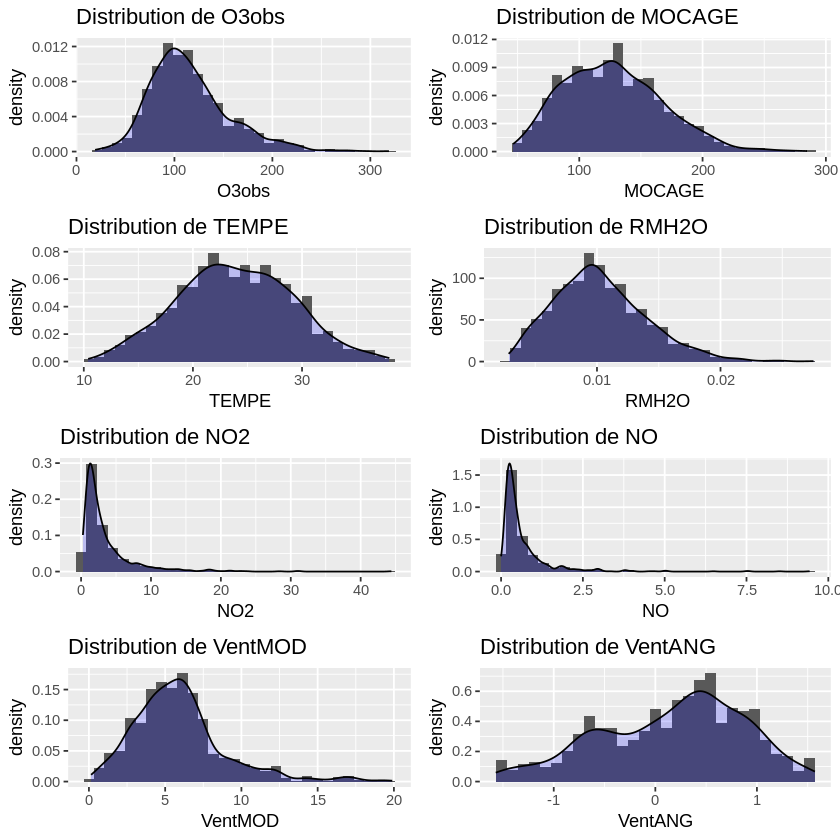

In [ ]:
# Création d'histogrammes pour les variables numériques
numeric_vars <- c("O3obs", "MOCAGE", "TEMPE", "RMH2O", "NO2", "NO", "VentMOD", "VentANG")

plots <- lapply(numeric_vars, function(var) {
  ggplot(ozone, aes_string(x = var)) +
    geom_histogram(aes(y = ..density..), bins = 30) +
    geom_density(alpha = 0.2, fill = "blue") +
    ggtitle(paste("Distribution de", var))
})

grid.arrange(grobs = plots, ncol = 2)


Ces visualisations nous permettent d'observer la distribution de chaque variable et d'identifier d'éventuelles asymétries ou valeurs aberrantes

## Transformations de variables

Certaines variables présentent des distributions asymétriques. Appliquons les transformations suggérées :


In [ ]:
ozone$SRMH2O <- sqrt(ozone$RMH2O)
ozone$LNO2 <- log(ozone$NO2)
ozone$LNO <- log(ozone$NO)

# Suppression des variables originales
ozone <- ozone[, c(1:4, 8:13)]

# Création de la variable de dépassement de seuil
ozone$DepSeuil <- as.factor(ifelse(ozone$O3obs > 150, 1, 0))


## Modèle gaussien de prévision

Modèle linéaire

Commençons par un modèle linéaire simple :


Call:
lm(formula = O3obs ~ MOCAGE + TEMPE + SRMH2O + LNO2 + LNO + VentMOD + 
    VentANG, data = ozone)

Residuals:
     Min       1Q   Median       3Q      Max 
-101.594  -17.592   -1.373   16.052  155.508 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) -10.42836    7.01672  -1.486 0.137527    
MOCAGE        0.56131    0.03875  14.486  < 2e-16 ***
TEMPE         3.70963    0.20002  18.546  < 2e-16 ***
SRMH2O      103.72557   51.88817   1.999 0.045868 *  
LNO2        -25.27388    4.87101  -5.189 2.55e-07 ***
LNO          23.21022    4.59218   5.054 5.11e-07 ***
VentMOD      -0.74687    0.32259  -2.315 0.020796 *  
VentANG       4.48744    1.31098   3.423 0.000644 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 28.14 on 1033 degrees of freedom
Multiple R-squared:  0.5321,	Adjusted R-squared:  0.5289 
F-statistic: 167.8 on 7 and 1033 DF,  p-value: < 2.2e-16


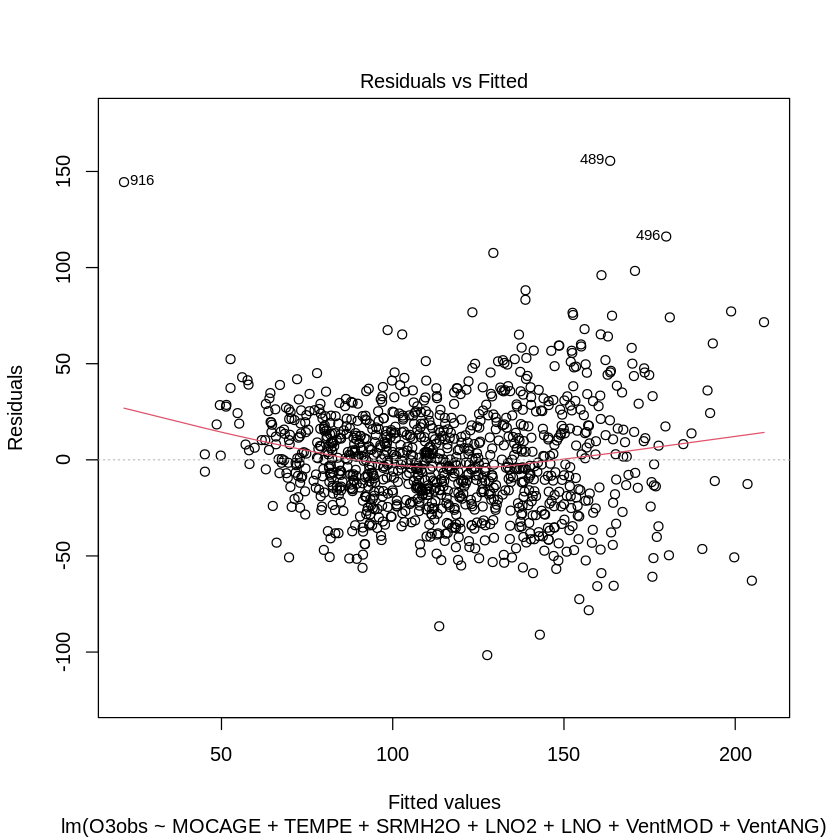

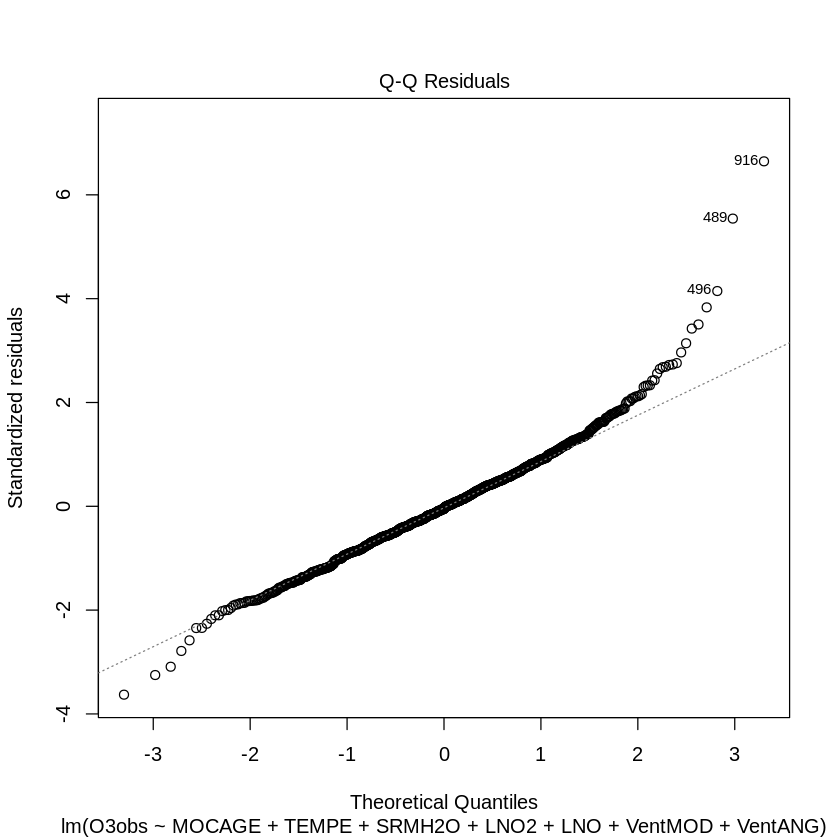

In [ ]:
mod_lin <- lm(O3obs ~ MOCAGE + TEMPE + SRMH2O + LNO2 + LNO + VentMOD + VentANG, data = ozone)
summary(mod_lin)

# Visualisation des résidus
plot(mod_lin, which = 1:2)


Modèle quadratique

Ajoutons maintenant des termes quadratiques :

In [ ]:
mod_quad <- lm(O3obs ~ MOCAGE + I(MOCAGE^2) + TEMPE + I(TEMPE^2) + SRMH2O + I(SRMH2O^2) +
               LNO2 + I(LNO2^2) + LNO + I(LNO^2) + VentMOD + I(VentMOD^2) + VentANG + I(VentANG^2),
               data = ozone)
summary(mod_quad)

# Comparaison des modèles
anova(mod_lin, mod_quad)



Call:
lm(formula = O3obs ~ MOCAGE + I(MOCAGE^2) + TEMPE + I(TEMPE^2) + 
    SRMH2O + I(SRMH2O^2) + LNO2 + I(LNO2^2) + LNO + I(LNO^2) + 
    VentMOD + I(VentMOD^2) + VentANG + I(VentANG^2), data = ozone)

Residuals:
    Min      1Q  Median      3Q     Max 
-87.693 -15.885  -0.088  14.331 136.492 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)   1.373e+02  2.295e+01   5.982 3.04e-09 ***
MOCAGE        1.075e+00  1.224e-01   8.776  < 2e-16 ***
I(MOCAGE^2)  -1.460e-03  3.996e-04  -3.652 0.000273 ***
TEMPE        -6.320e+00  1.181e+00  -5.353 1.06e-07 ***
I(TEMPE^2)    2.147e-01  2.409e-02   8.912  < 2e-16 ***
SRMH2O       -7.332e+02  3.663e+02  -2.002 0.045563 *  
I(SRMH2O^2)   4.156e+03  1.792e+03   2.319 0.020603 *  
LNO2         -3.645e+01  5.134e+00  -7.100 2.32e-12 ***
I(LNO2^2)    -4.673e+00  1.285e+00  -3.637 0.000289 ***
LNO           5.022e+01  6.282e+00   7.994 3.50e-15 ***
I(LNO^2)      5.351e+00  8.787e-01   6.089 1.60e-09 ***
VentMOD      -1

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1033,818000.7,NA,NA,NA,NA
2,1026,715830.3,7,102170.4,20.92014,1.943624e-26


Évaluation des modèles

Pour évaluer les modèles, nous allons utiliser une validation croisée :

In [ ]:
set.seed(123)
n <- nrow(ozone)
train_index <- sample(1:n, 0.7*n)
train_data <- ozone[train_index, ]
test_data <- ozone[-train_index, ]

# Fonction pour calculer l'erreur quadratique moyenne
rmse <- function(actual, predicted) {
  sqrt(mean((actual - predicted)^2))
}

# Évaluation du modèle linéaire
pred_lin <- predict(mod_lin, newdata = test_data)
rmse_lin <- rmse(test_data$O3obs, pred_lin)

# Évaluation du modèle quadratique
pred_quad <- predict(mod_quad, newdata = test_data)
rmse_quad <- rmse(test_data$O3obs, pred_quad)

cat("RMSE modèle linéaire:", rmse_lin, "\n")
cat("RMSE modèle quadratique:", rmse_quad, "\n")


RMSE modèle linéaire: 27.91718 
RMSE modèle quadratique: 26.82744 


Modèle binomial de prévision

Régression logistique


Call:
glm(formula = DepSeuil ~ MOCAGE + TEMPE + SRMH2O + LNO2 + LNO + 
    VentMOD + VentANG, family = binomial, data = ozone)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept) -15.962083   1.330248 -11.999  < 2e-16 ***
MOCAGE        0.021722   0.004861   4.468 7.88e-06 ***
TEMPE         0.306167   0.030986   9.881  < 2e-16 ***
SRMH2O       28.572535   6.610836   4.322 1.55e-05 ***
LNO2         -0.020356   0.651636  -0.031    0.975    
LNO          -0.363792   0.614038  -0.592    0.554    
VentMOD      -0.023196   0.049934  -0.465    0.642    
VentANG       0.255770   0.170159   1.503    0.133    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 952.41  on 1040  degrees of freedom
Residual deviance: 565.84  on 1033  degrees of freedom
AIC: 581.84

Number of Fisher Scoring iterations: 6


Setting levels: control = 0, case = 1

Setting direction: controls < cases



Area under the curve: 0.9091

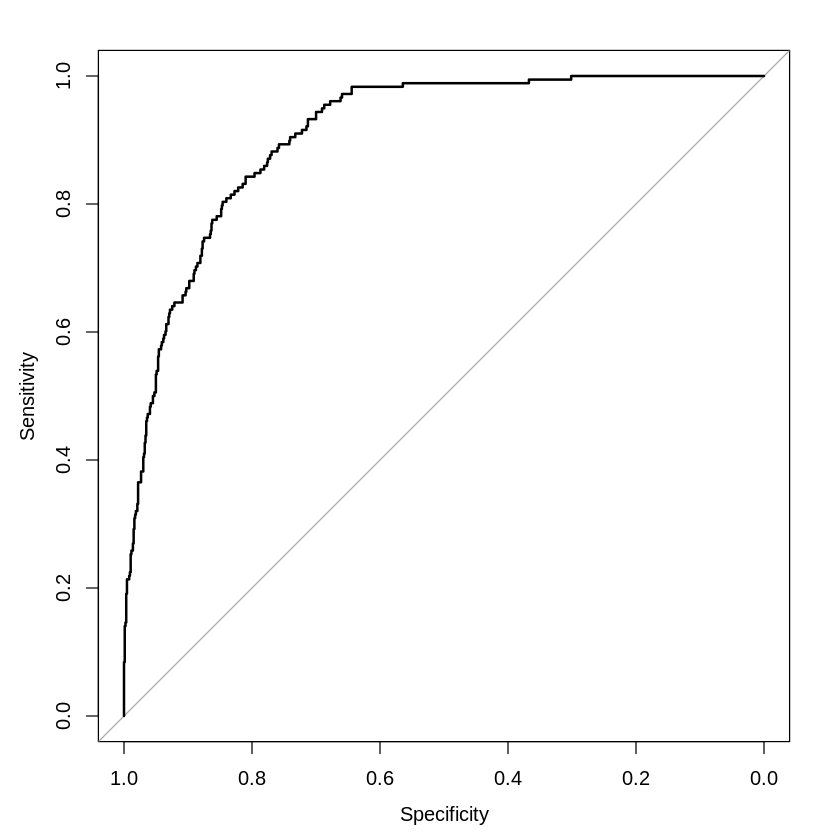

In [ ]:
mod_log <- glm(DepSeuil ~ MOCAGE + TEMPE + SRMH2O + LNO2 + LNO + VentMOD + VentANG,
               family = binomial, data = ozone)
summary(mod_log)

# Courbe ROC
roc_curve <- roc(ozone$DepSeuil, predict(mod_log, type = "response"))
plot(roc_curve)
auc(roc_curve)


Régression logistique avec interactions

In [ ]:
mod_log_int <- glm(DepSeuil ~ (MOCAGE + TEMPE + SRMH2O + LNO2 + LNO + VentMOD + VentANG)^2,
                   family = binomial, data = ozone)
summary(mod_log_int)

# Comparaison des modèles
anova(mod_log, mod_log_int, test = "Chisq")



Call:
glm(formula = DepSeuil ~ (MOCAGE + TEMPE + SRMH2O + LNO2 + LNO + 
    VentMOD + VentANG)^2, family = binomial, data = ozone)

Coefficients:
                  Estimate Std. Error z value Pr(>|z|)    
(Intercept)     -3.544e+01  1.193e+01  -2.971 0.002966 ** 
MOCAGE          -3.810e-02  5.946e-02  -0.641 0.521710    
TEMPE            1.843e-01  3.990e-01   0.462 0.644176    
SRMH2O           7.432e+01  8.124e+01   0.915 0.360296    
LNO2             2.671e+01  8.173e+00   3.268 0.001084 ** 
LNO             -2.738e+01  8.028e+00  -3.411 0.000648 ***
VentMOD         -4.126e-01  6.952e-01  -0.593 0.552886    
VentANG          1.093e-01  2.354e+00   0.046 0.962980    
MOCAGE:TEMPE    -1.749e-03  1.668e-03  -1.049 0.294289    
MOCAGE:SRMH2O    1.512e+00  4.515e-01   3.349 0.000812 ***
MOCAGE:LNO2     -2.671e-02  1.322e-02  -2.021 0.043245 *  
MOCAGE:LNO       2.996e-02  1.475e-02   2.031 0.042227 *  
MOCAGE:VentMOD   4.812e-03  3.560e-03   1.352 0.176462    
MOCAGE:VentANG  -1.957e-03 

,Resid. Df,Resid. Dev,Df,Deviance,Pr(>Chi)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1033,565.8379,NA,NA,NA
2,1012,510.8688,21,54.9691,7.142944e-05


Arbres de décision binaires

Pour les arbres de décision, nous utiliserons la bibliothèque rpart :

Loading required package: rpart

Loading required package: rpart.plot

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘rpart.plot’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



,JOUR,O3obs,MOCAGE,TEMPE,RMH2O,NO2,NO,STATION,VentMOD,VentANG
,<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>
1,1,91,93.2,21.5,0.00847,1.602,0.424,Aix,9.5000,-0.64350
2,1,100,104.6,20.2,0.00881,2.121,0.531,Aix,8.0100,-0.04996
3,0,82,103.6,17.4,0.00951,1.657,0.467,Aix,9.3771,-0.12832
4,0,94,94.8,18.8,0.00855,2.350,0.701,Aix,9.4578,-0.34516
5,0,107,99.0,23.7,0.00731,1.653,0.452,Aix,7.8791,-0.41822
6,0,150,114.3,23.6,0.01182,5.316,1.343,Aix,6.3127,0.06341


 JOUR        O3obs           MOCAGE          TEMPE           RMH2O        
 0:724   Min.   : 19.0   Min.   : 46.4   Min.   :10.40   Min.   :0.00285  
 1:317   1st Qu.: 87.0   1st Qu.: 97.5   1st Qu.:20.20   1st Qu.:0.00763  
         Median :109.0   Median :125.6   Median :23.80   Median :0.00985  
         Mean   :115.4   Mean   :127.2   Mean   :23.88   Mean   :0.01025  
         3rd Qu.:135.0   3rd Qu.:153.6   3rd Qu.:27.60   3rd Qu.:0.01244  
         Max.   :319.0   Max.   :284.7   Max.   :38.00   Max.   :0.02753  
      NO2               NO         STATION      VentMOD       
 Min.   : 0.258   Min.   :0.0010   Aix:199   Min.   : 0.1414  
 1st Qu.: 1.248   1st Qu.:0.2360   Als:222   1st Qu.: 3.9623  
 Median : 2.109   Median :0.3880   Cad:202   Median : 5.5973  
 Mean   : 3.505   Mean   :0.6574   Pla:208   Mean   : 5.9072  
 3rd Qu.: 4.062   3rd Qu.:0.7440   Ram:210   3rd Qu.: 7.1063  
 Max.   :44.396   Max.   :9.4290             Max.   :19.8910  
    VentANG       
 Min.   :-1.570

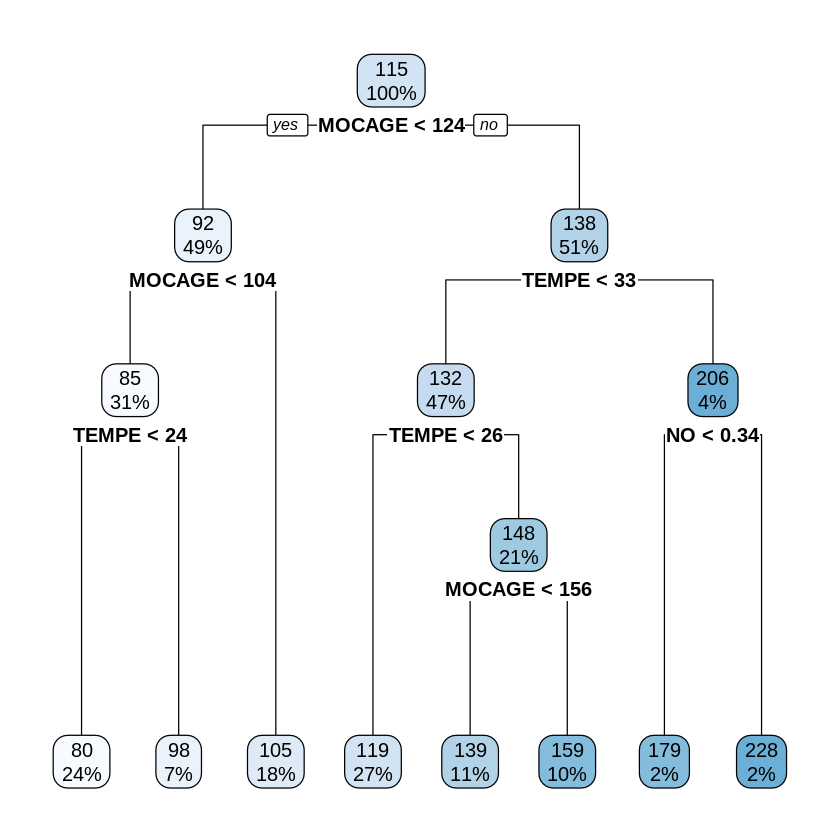

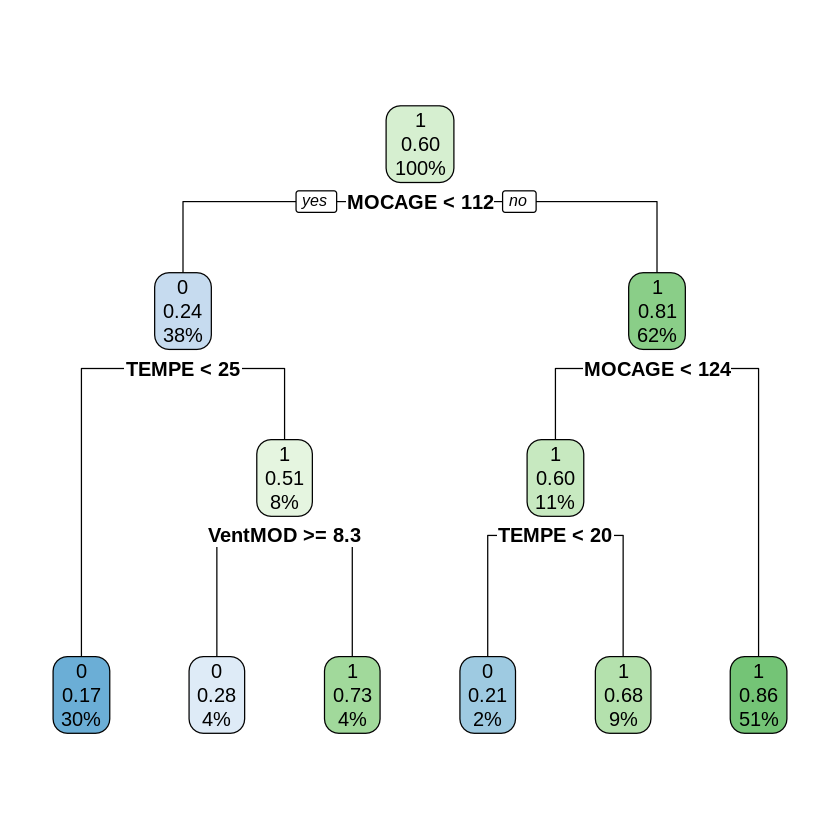

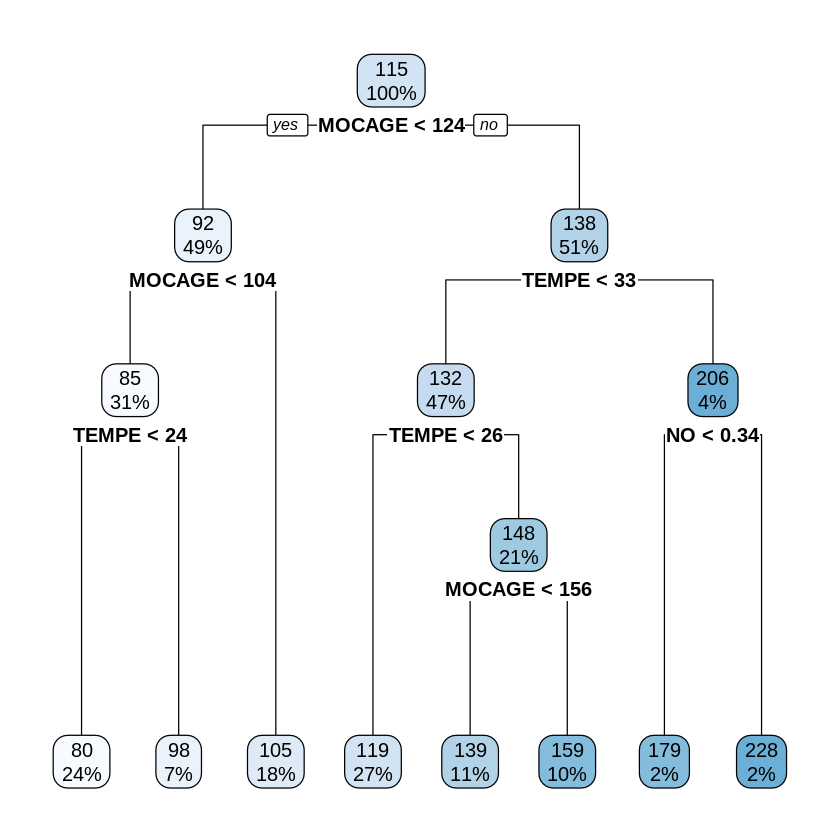

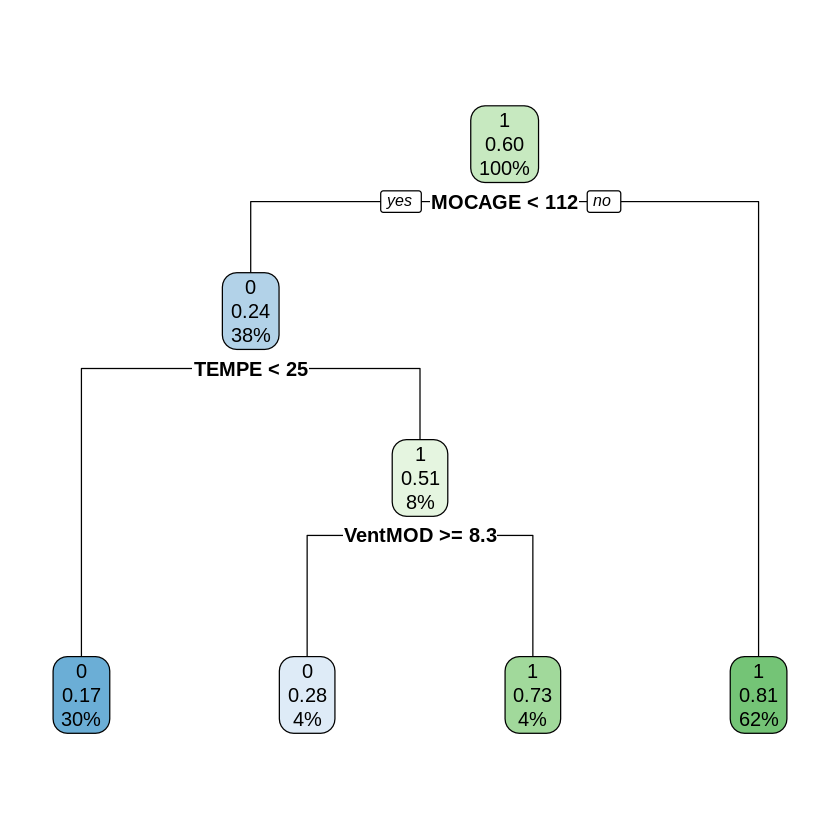

In [ ]:
# Install and load necessary packages
if(!require('rpart')) {install.packages('rpart'); library(rpart)}
if(!require('rpart.plot')) {install.packages('rpart.plot'); library(rpart.plot)}

# Define the path to the data
path <- "http://www.math.univ-toulouse.fr/~besse/Wikistat/data/"

# Read the data from the URL
ozone <- read.table(paste(path, "depSeuil.dat", sep = ""),
                    sep = ",", header = TRUE)

# Conversion of qualitative variables to factors
ozone$JOUR <- as.factor(ozone$JOUR)
ozone$STATION <- as.factor(ozone$STATION)

# Display the first few rows and summary statistics
head(ozone)
summary(ozone)

# Ensure DepSeuil exists
if(!"DepSeuil" %in% colnames(ozone)) {
    # Example: Create DepSeuil based on O3obs threshold
    ozone$DepSeuil <- as.factor(ifelse(ozone$O3obs > 100, 1, 0))
}

# Regression tree
tree_reg <- rpart(O3obs ~ MOCAGE + TEMPE + RMH2O + NO2 + NO + VentMOD + VentANG,
                  data = ozone, method = "anova")
rpart.plot(tree_reg)

# Classification tree
tree_class <- rpart(DepSeuil ~ MOCAGE + TEMPE + RMH2O + NO2 + NO + VentMOD + VentANG,
                    data = ozone, method = "class")
rpart.plot(tree_class)

# Pruning the trees
pruned_reg <- prune(tree_reg, cp = tree_reg$cptable[which.min(tree_reg$cptable[,"xerror"]), "CP"])
pruned_class <- prune(tree_class, cp = tree_class$cptable[which.min(tree_class$cptable[,"xerror"]), "CP"])

rpart.plot(pruned_reg)
rpart.plot(pruned_class)


Réseaux de neurones

Pour les réseaux de neurones, nous utiliserons la bibliothèque nnet :

In [ ]:
library(nnet)

# Normalisation des données
normalize <- function(x) {
  return ((x - min(x)) / (max(x) - min(x)))
}

ozone_norm <- as.data.frame(lapply(ozone[, c("MOCAGE", "TEMPE", "SRMH2O", "LNO2", "LNO", "VentMOD", "VentANG")], normalize))
ozone_norm$O3obs <- ozone$O3obs
ozone_norm$DepSeuil <- ozone$DepSeuil

# Réseau de neurones pour la régression
nn_reg <- nnet(O3obs ~ MOCAGE + TEMPE + SRMH2O + LNO2 + LNO + VentMOD + VentANG,
               data = ozone_norm, size = 5, linout = TRUE, maxit = 1000)

# Réseau de neurones pour la classification
nn_class <- nnet(DepSeuil ~ MOCAGE + TEMPE + SRMH2O + LNO2 + LNO + VentMOD + VentANG,
                 data = ozone_norm, size = 5, maxit = 1000)

# Évaluation des modèles
pred_nn_reg <- predict(nn_reg, newdata = ozone_norm)
rmse_nn <- rmse(ozone_norm$O3obs, pred_nn_reg)

pred_nn_class <- predict(nn_class, newdata = ozone_norm, type = "class")
conf_matrix <- table(ozone_norm$DepSeuil, pred_nn_class)
accuracy <- sum(diag(conf_matrix)) / sum(conf_matrix)

cat("RMSE réseau de neurones (régression):", rmse_nn, "\n")
cat("Précision réseau de neurones (classification):", accuracy, "\n")


ERROR: Error in `[.data.frame`(ozone, , c("MOCAGE", "TEMPE", "SRMH2O", "LNO2", : undefined columns selected


In [ ]:
# Correct column names and create transformations if needed
ozone$LNO2 <- log(ozone$NO2 + 1)  # Adding 1 to avoid log(0)
ozone$LNO <- log(ozone$NO + 1)

# Normalisation des données
normalize <- function(x) {
    return ((x - min(x)) / (max(x) - min(x)))
}

ozone_norm <- as.data.frame(lapply(ozone[, c("MOCAGE", "TEMPE", "RMH2O", "LNO2", "LNO", "VentMOD", "VentANG")], normalize))
ozone_norm$O3obs <- ozone$O3obs
ozone_norm$DepSeuil <- ozone$DepSeuil

# Réseau de neurones pour la régression
library(nnet)
nn_reg <- nnet(O3obs ~ MOCAGE + TEMPE + RMH2O + LNO2 + LNO + VentMOD + VentANG,
               data = ozone_norm, size = 5, linout = TRUE, maxit = 1000)

# Réseau de neurones pour la classification
nn_class <- nnet(DepSeuil ~ MOCAGE + TEMPE + RMH2O + LNO2 + LNO + VentMOD + VentANG,
                 data = ozone_norm, size = 5, maxit = 1000)

# Évaluation des modèles
pred_nn_reg <- predict(nn_reg, newdata = ozone_norm)
rmse_nn <- sqrt(mean((ozone_norm$O3obs - pred_nn_reg)^2))

pred_nn_class <- predict(nn_class, newdata = ozone_norm, type = "class")
conf_matrix <- table(ozone_norm$DepSeuil, pred_nn_class)
accuracy <- sum(diag(conf_matrix)) / sum(conf_matrix)

cat("RMSE réseau de neurones (régression):", rmse_nn, "\n")
cat("Précision réseau de neurones (classification):", accuracy, "\n")


# weights:  46
initial  value 15558453.011026 
final  value 1748167.959654 
converged
# weights:  46
initial  value 842.427170 
iter  10 value 468.380420
iter  20 value 434.863346
iter  30 value 428.847475
iter  40 value 419.206746
iter  50 value 416.492931
iter  60 value 414.358665
iter  70 value 413.102506
iter  80 value 411.261836
iter  90 value 410.270185
iter 100 value 409.929489
iter 110 value 409.181038
iter 120 value 408.248069
iter 130 value 407.911810
iter 140 value 407.629849
iter 150 value 407.479557
iter 160 value 407.046484
iter 170 value 406.187375
iter 180 value 405.618355
iter 190 value 405.405337
iter 200 value 405.374082
iter 210 value 405.290642
iter 220 value 405.170583
iter 230 value 404.559790
iter 240 value 404.238061
iter 250 value 404.135831
iter 260 value 404.100557
iter 270 value 403.908462
iter 280 value 402.927068
iter 290 value 402.829458
iter 300 value 402.535259
iter 310 value 401.582875
iter 320 value 400.925408
iter 330 value 399.853708
iter 340 value

conclusion


Ce projet m’a permis de renforcer mes compétences dans l’utilisation du langage R, notamment dans la manipulation de données, l’élaboration de modèles prédictifs avec des arbres de décision, et l’optimisation par élagage. En appliquant l'algorithme d'élagage, j'ai appris à contrôler la complexité d'un modèle pour améliorer son interprétabilité et éviter le sur-apprentissage.

Ce travail m’a également aidé à mieux comprendre les concepts liés à l’entropie, aux critères de division et à la généralisation des modèles. La visualisation des résultats a été un point fort, rendant les décisions du modèle plus transparentes et compréhensibles.

Enfin, cette expérience m’a donné une meilleure perspective sur l’importance de l’équilibre entre la précision du modèle et sa simplicité, tout en consolidant mes bases en science des données et en analyse statistique.